<h1><center> <ins><b> Monte Carlo Simulation </b></ins></center></h1>

## European Options in the Black-Scholes World

Here we have constant interest rate so the discount factor is $e^{-r\,\left(T-t\right)}$, and the stock dynamics are modelled with Geometric Brownian Motion (GBM).

$$ dS_t = rS_tdt+\sigma S_tdW_t$$

Let's simulate this GBM process by simulating variables of the natural logarithm process of the stock price $x_t = ln(S_t)$, which is normally distributed. For the dynamics of the natural logarithm process of stock prices under GBM model, we need to use Ito's calculus.

$$ dx_t = \nu dt+\sigma dz_t ,  \nu = r - \frac{1}{2} \sigma ^ 2$$

We can then discretize the Stochastic Differential Equation (SDE) by changing the infinitesimals $dx, dt, dz$ into small steps $\Delta x, \Delta t, \Delta z$.

$$ \Delta x = \nu  \Delta t+\sigma \Delta z$$

This is the exact solution to the SDE and involves no approximation.

$$ x_{t+\Delta t} = x_{t} + \nu (\Delta t)+\sigma (z_{t+\Delta t}- z_t)$$

In terms of the stock price S, we have:

$$ S_{t+\Delta t} = S_{t} \exp( \nu \Delta t + \sigma (z_{t+\Delta t}- z_t) )$$

Where $(z_{t+\Delta t}- z_t) \sim N(0,\Delta t) \sim \sqrt{\Delta t} N(0,1) \sim \sqrt{\Delta t} \epsilon_i$

3 steps:
1. Simulate Stock Price Trends:
    - Discretize time into small steps.
    - Generate random numbers representing daily price changes using the geometric Brownian motion formula, which incorporates volatility and randomness.
    - Simulate thousands of different price paths for the stock over the option’s life.
<br><br>
2. Calculate Option Payoff:
    - For each simulated path, calculate the option payoff at maturity based on the final stock price and the strike price. This is simply the maximum of the difference between the stock price and the strike price (zero if negative).
<br><br>
3. Estimate Option Price:
    - Average the option payoffs from all simulated paths.
    - Discount this average payoff back to the present using the risk-free rate and time to maturity. This gives the estimated price of the call option.

In [42]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
import datetime
import time

Let us investiage quickly how we can simulate stock price trends

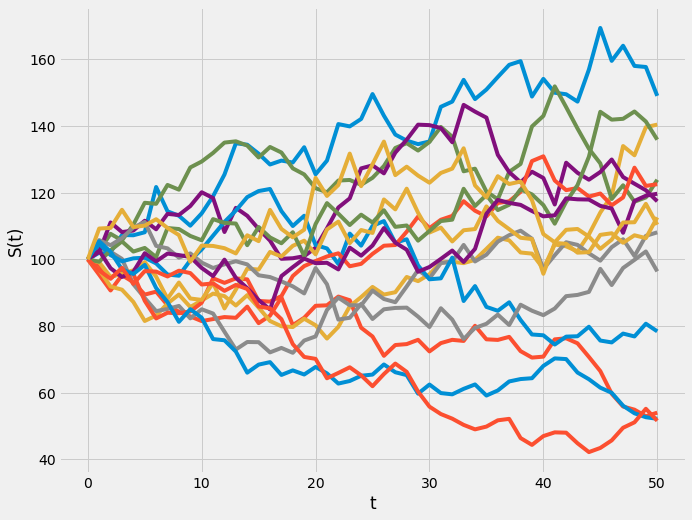

In [59]:
r=0.06
sigma = 0.3
T = 1.0
S0 = 100

I = 1000
M = 50

dt = T/M

S = np.zeros((M+1, I))
S[0] = S0
for t in range(1,M+1):
    S[t] = S[t-1]*np.exp((r -0.5*sigma**2)*dt +sigma*np.sqrt(dt)*np.random.standard_normal(I))

plt.figure(figsize=(10, 8))
plt.plot(S[:, :15])
plt.xlabel('t')
plt.ylabel('S(t)')
plt.show()

For the purposes of this notebook, we will make up our parameters. In other notebooks, we will use real data to support our findings.

In [55]:
# Initial parameters
S = 200        #Underlying asset price
K = 180        #Strike Price
r = 0.05       #Rate free interest rate
q = 0          #Continuous Dividend Yield
sigma = 0.3    #Volatility
T = 1          #Time to expiry from start of contract
t = 0.5        #Current time
N = 10         #Number of timesteps
I = 10000000   #Number of iterations

## Method 1

In [56]:
# To time how long our block of code takes to compute
t0 = time.time()

# Precompute constants
dt = (T-t)/N
nudt = (r - 0.5*sigma**2)*dt
volsdt = sigma*np.sqrt(dt)
lnS = np.log(S)

# Standard Error Placeholders
sum_CT = 0
sum_CT2 = 0
sum_PT = 0
sum_PT2 = 0

# Monte Carlo Method
np.random.seed(0)
for i in range(I):
    lnSt = lnS
    for j in range(N):
        lnSt = lnSt + nudt + volsdt*np.random.normal()

    ST = np.exp(lnSt)
    CT = max(0, ST - K)
    sum_CT = sum_CT + CT
    sum_CT2 = sum_CT2 + CT*CT
    PT = max(0, K - ST)
    sum_PT = sum_PT + PT
    sum_PT2 = sum_PT2 + PT*PT

# Compute Expectation and Standard Error
C0 = np.exp(-r*(T-t))*sum_CT/I
SE1 = (np.sqrt((sum_CT2 - sum_CT*sum_CT/I)*np.exp(-2*r*(T-t)) / (I-1)))/np.sqrt(I)
P0 = np.exp(-r*(T-t))*sum_PT/I
SE2 = (np.sqrt((sum_PT2 - sum_PT*sum_PT/I)*np.exp(-2*r*(T-t)) / (I-1)))/np.sqrt(I)

print(f'The value of the European Call is {round(C0,2)} with a Standard Error of +/- {round(SE1,3)}')
print(f'The value of the European Put is {round(P0,2)} with a Standard Error of +/- {round(SE2,3)}')

t1 = time.time()
total = t1-t0

print(f'\n\nThe time elapsed using Method 1 is {round(total,3)} seconds')

The value of the European Call is 30.98 with a Standard Error of +/- 0.011
The value of the European Put is 6.53 with a Standard Error of +/- 0.004


The time elapsed using Method 1 is 191.593 seconds


<br><br>
Although this method does work, note how we are running 2 for loops and as we increase the number of time steps and simulations, the time necessary to perform the time complexity will grow. Let us think about how we can avoid using for loops and ways to reduce this. 

## Method 2


For our needs (European Options), we only care about the final timestep, ie. when our option expires. It is not the case where we need information of the exact path it took to get there. Hence, we can forget about time steps and just perform the final time step calculations.
<br><br>
Moreover, instead of using for loops, we will construct a 2xI matrix of zeros and a 1xI matrix (where I is the number of simulations) full of normally distributed random numbers with a mean of 0 and standard deviation of 1. Then we will calculate, using the same way above, what the value of the asset would be at expiry. After this, we will substract the Strike Price and enter this 1xI matrix into the bottom row of the 2xI matrix. Then using the fact that the payoff of a call option is $\text{max}(S-K,0)$, we will compare the $a_{1n}$ and $a_{2n}$ entries of the matrix and take the maximum, sum all of them and then divide by I. Finally, multiplying this by $e^{-r(T-t)}$ to account for the rate-free interest rate as the time has passed, we end up with our estimate for the value of the option call.
<br><br>
We will do the same for European Put Options except now, our payoff is $\text{max}(K-S,0)$.
<br><br>
Let us implement this methodology into code:

In [57]:
# Taking note of initial current time
t0 = time.time()

# Creating our 2xI matrix of zeros
data = np.zeros((2, I))
data2 = np.zeros((2, I))

# Creating our 1xI matrix of normally distributed random numbers
np.random.seed(0)
z = np.random.normal(0, 1, [1, I])

# Calculating value of asset at expiry
ST = S*np.exp((T-t)*(r - 0.5*sigma**2)+sigma*np.sqrt(T-t)*z)
#print(ST)

# Subtracting each value by the Strike Price and entering these into the bottom row of our 2xI matrix
data[-1] = ST - K
data2[-1] = K - ST
#print(data)

# Take the maximum of each column (either S-K or 0) and form an array from these
maxi = np.amax(data, axis=0)
maxi2 = np.amax(data2, axis=0)
#print(maxi)

# Sum the maximums and divide by the number of iterations
average = np.sum(np.amax(data, axis=0))/float(I)
average2 = np.sum(np.amax(data2, axis=0))/float(I)
#print(average)

# Multiply this by exp(-r(T-t)) to take account of the rate-free interest rate
final=np.exp(-r*(T-t))*average
final2=np.exp(-r*(T-t))*average2

# Calculations to find the Standard Error
SE3 = (np.sqrt((np.sum((maxi - average)**2)) / (I-1)))/np.sqrt(I)
SE4 = (np.sqrt((np.sum((maxi2 - average2)**2)) / (I-1)))/np.sqrt(I)

print(f'The value of the European Call is {round(final,2)} with a Standard Error of +/- {round(SE3,3)}')
print(f'The value of the European Put is {round(final2,2)} with a Standard Error of +/- {round(SE4,3)}')

# Time after calculations to find total time elapsed by taking away initial time
t1 = time.time()
total2 = t1-t0

print(f'\n\nThe time elapsed using Method 2 is {round(total2,3)} seconds')

The value of the European Call is 30.98 with a Standard Error of +/- 0.012
The value of the European Put is 6.52 with a Standard Error of +/- 0.004


The time elapsed using Method 2 is 1.116 seconds


## Efficiency comparison between the 2 methods

To numerically and accurately compare the efficiency of both codes, we will use the 2 lengths of time it took to run the code that we calculated and divide the slower by the faster and multiply by 100.

In [58]:
eff = (total/total2)*100
print(f'The faster method is roughly {int(eff)}% more efficient')

The faster method is roughly 17166% more efficient
